In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv("fake_job_postings.csv")

In [9]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [10]:
df.shape

(17880, 18)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [12]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

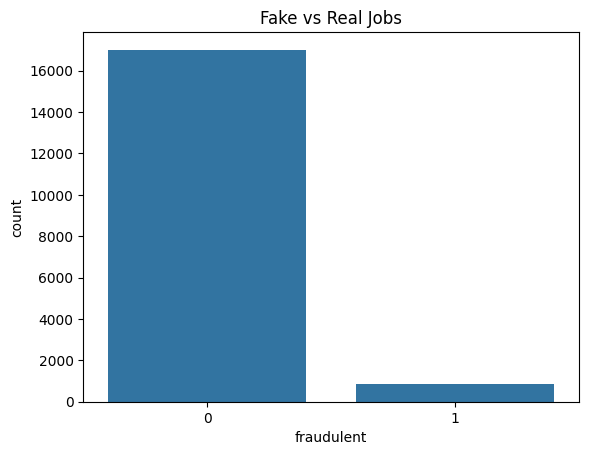

In [13]:
sns.countplot(x='fraudulent', data=df)

plt.title("Fake vs Real Jobs")

plt.show()

In [14]:
df['text'] = (
    df['title'].fillna('') + " " +
    df['company_profile'].fillna('') + " " +
    df['description'].fillna('') + " " +
    df['requirements'].fillna('') + " " +
    df['benefits'].fillna('')
)

In [15]:
nltk.download('stopwords')

nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\thaku\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\thaku\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [16]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [17]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [18]:
df['clean_text'] = df['text'].apply(clean_text)

In [19]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

y = df['fraudulent']

In [20]:
smote = SMOTE(random_state=42)

X, y = smote.fit_resample(X, y)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
models = {

    "Logistic Regression":
    LogisticRegression(),

    "Naive Bayes":
    MultinomialNB(),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Random Forest":
    RandomForestClassifier(),

    "SVM":
    LinearSVC(),

    "KNN":
    KNeighborsClassifier(),

    "Gradient Boosting":
    GradientBoostingClassifier(),

    "XGBoost":
    XGBClassifier()
}

In [23]:
accuracy_list = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_list.append([name, accuracy])

    print(name, "Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9847193652659418
Naive Bayes Accuracy: 0.9484278577725537
Decision Tree Accuracy: 0.9723773141345872
Random Forest Accuracy: 0.9976491331178372
SVM Accuracy: 0.9944166911548633
KNN Accuracy: 0.8774610637672642
Gradient Boosting Accuracy: 0.9709080223332354
XGBoost Accuracy: 0.9928004701733765


In [24]:
accuracy_df = pd.DataFrame(
    accuracy_list,
    columns=['Model', 'Accuracy']
)

accuracy_df

,Model,Accuracy
0,Logistic Regression,0.984719
1,Naive Bayes,0.948428
2,Decision Tree,0.972377
3,Random Forest,0.997649
4,SVM,0.994417
5,KNN,0.877461
6,Gradient Boosting,0.970908
7,XGBoost,0.992800


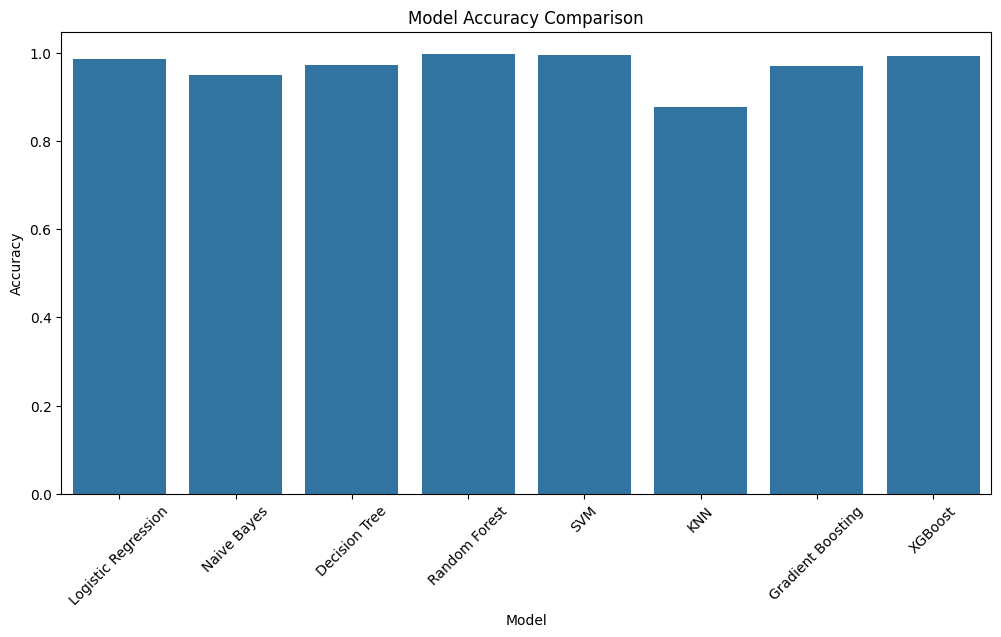

In [25]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=accuracy_df
)

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.show()

In [26]:
accuracy_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
3,Random Forest,0.997649
4,SVM,0.994417
7,XGBoost,0.992800
0,Logistic Regression,0.984719
2,Decision Tree,0.972377
6,Gradient Boosting,0.970908
1,Naive Bayes,0.948428
5,KNN,0.877461


In [27]:
import pickle

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

pickle.dump(
    rf,
    open("fake_job_model.pkl", "wb")
)

pickle.dump(
    tfidf,
    open("tfidf_vectorizer.pkl", "wb")
)